In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import math

In [ ]:
# Levy flight для генерації випадкових кроків
def levy_flight(dim, beta=1.5):
    sigma = (
        math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
        (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / (np.abs(v) ** (1 / beta) + 1e-8)

# Алгоритм пошуку зозулі (оптимізація)
def cuckoo_search(func, dim, bounds, n_nests=25, n_iter=100, pa=0.25):
    lower, upper = bounds
    nests = np.random.uniform(lower, upper, (n_nests, dim)) 
    fitness = np.array([func(x) for x in nests])

    best_idx = np.argmin(fitness)
    best = nests[best_idx].copy()
    best_val = fitness[best_idx]
    convergence = []

    for _ in range(n_iter):
        for i in range(n_nests):
            step = levy_flight(dim)
            new = nests[i] + 0.01 * step * (best - nests[i])
            new = np.clip(new, lower, upper)

            fnew = func(new)
            if fnew < fitness[i]:  # Прийняття кращого рішення
                nests[i] = new
                fitness[i] = fnew

        abandon = np.random.rand(n_nests) < pa # Частина гнізд замінюється
        nests[abandon] = np.random.uniform(lower, upper, (np.sum(abandon), dim))

        for j in np.where(abandon)[0]:
            fitness[j] = func(nests[j])

        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_val:  # Оновлення глобального найкращого
            best = nests[best_idx].copy()
            best_val = fitness[best_idx]

        convergence.append(best_val)

    return convergence, best_val

# Алгоритм кажанів
def bat_algorithm(func, dim, bounds, n_bats=25, n_iter=100):
    lower, upper = bounds
    X = np.random.uniform(lower, upper, (n_bats, dim))  
    V = np.zeros((n_bats, dim)) 
    fitness = np.array([func(x) for x in X])

    A = np.ones(n_bats) * 1.5 
    r = np.zeros(n_bats) 
    alpha = 0.9
    gamma = 0.9
    fmin, fmax = 0, 2

    best_idx = np.argmin(fitness)
    best = X[best_idx].copy()
    best_val = fitness[best_idx]
    convergence = []

    for t in range(n_iter):
        for i in range(n_bats):
            freq = fmin + (fmax - fmin) * np.random.rand()
            V[i] += (best - X[i]) * freq
            candidate = np.clip(X[i] + V[i], lower, upper)

            if np.random.rand() > r[i]:
                candidate = np.clip(best + 0.01 * np.random.randn(dim), lower, upper)

            fnew = func(candidate)
            if fnew < fitness[i] and np.random.rand() < A[i]:
                X[i] = candidate
                fitness[i] = fnew
                A[i] *= alpha
                r[i] = 1 - np.exp(-gamma * t)

        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_val:  # Оновлення найкращого рішення
            best = X[best_idx].copy()
            best_val = fitness[best_idx]

        convergence.append(best_val)

    return convergence, best_val

### Завдання 2

In [ ]:
# Функція Растрігіна
def rastrigin(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Функція Mishra Bird (складна 2D функція)
def mishra_bird(x):
    x1, x2 = x
    return (
        np.exp((1 - np.cos(x1))**2) * np.sin(x2) +
        np.exp((1 - np.sin(x2))**2) * np.cos(x1) +
        (x1 - x2)**2
    )

# Анімація збіжності та розподілу значень
def animate_task(histories, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    histories = np.array(histories)

    n_runs = histories.shape[0]
    n_iter = histories.shape[1]

    y_min = np.min(histories) - 5
    y_max = np.max(histories) + 5
    max_count = n_runs

  # Оновлення кадру анімації
    def update(frame):
        ax1.clear()
        ax2.clear()

        for i in range(n_runs):
            ax1.plot(histories[i, :frame + 1], alpha=0.3)

         # Середнє значення
        mean_vals = np.mean(histories[:, :frame + 1], axis=0)
        ax1.plot(mean_vals, linewidth=2, linestyle='--', label='Mean')

        ax1.set_xlim(0, n_iter)
        ax1.set_ylim(y_min, y_max)
        ax1.set_title("Збіжність")
        ax1.set_xlabel("Ітерація")
        ax1.set_ylabel("f(x)")
        ax1.legend(loc='upper right')

         # Гістограма значень
        current_vals = histories[:, frame]
        ax2.hist(current_vals, bins=min(10, n_runs), edgecolor='black')
        ax2.set_title("Розподіл значень")
        ax2.set_xlabel("f(x)")
        ax2.set_ylabel("Кількість запусків")
        ax2.set_xlim(y_min, y_max)
        ax2.set_ylim(0, max_count)

        fig.suptitle(title)

    anim = FuncAnimation(fig, update, frames=n_iter, interval=50)
    anim.save(f"{filename}.gif", writer="pillow", fps=15)
    plt.close()
    print(f"Успішно збережено як файл {filename}.gif")
    print("\n")


# Запуск експериментів
def run_task2():
    RUNS = 5
    ITER = 150

    # Межі для функцій
    bounds_rastrigin = (np.full(20, -5.12), np.full(20, 5.12))
    bounds_mishra = (np.array([-10.0, -6.5]), np.array([0.0, 0.0]))

    tasks = [
        (cuckoo_search, rastrigin, 20, bounds_rastrigin, "Cuckoo - Rastrigin", "cuckoo_rastrigin"),
        (bat_algorithm, rastrigin, 20, bounds_rastrigin, "Bat - Rastrigin", "bat_rastrigin"),
        (cuckoo_search, mishra_bird, 2, bounds_mishra, "Cuckoo - Mishra", "cuckoo_mishra"),
        (bat_algorithm, mishra_bird, 2, bounds_mishra, "Bat - Mishra", "bat_mishra"),
    ]

    print("---------------------------------------------------------------")
    print("Завдання 2")
    print()

    for algo, func, dim, bounds, title, filename in tasks:
        print(f"{title}...")
        all_hist = []

        for _ in range(RUNS):
            h, _ = algo(func, dim, bounds, n_iter=ITER)
            all_hist.append(h)

        animate_task(all_hist, title, filename)

    print("---------------------------------------------------------------")


run_task2()

---------------------------------------------------------------
Завдання 2

Cuckoo - Rastrigin...
Успішно збережено як файл cuckoo_rastrigin.gif


Bat - Rastrigin...
Успішно збережено як файл bat_rastrigin.gif


Cuckoo - Mishra...
Успішно збережено як файл cuckoo_mishra.gif


Bat - Mishra...
Успішно збережено як файл bat_mishra.gif


---------------------------------------------------------------


### Завдання 3

In [ ]:
B3 = 2.0  # Цільове значення

# Права частина системи диференціальних рівнянь
def system_rhs_task3(t, state):
    x, dx, y = state

# Обмеження значень для стабільності
    x = np.clip(x, -50, 50)
    dx = np.clip(dx, -50, 50)
    y = np.clip(y, -10, 10)

    # Обчислення похідних
    dy = y**4 + x**3 - 3 * np.sin(t) * dx
    ddx = x**2 * t**2 - (dy**2) * np.cos(dx)

    return np.array([dx, ddx, dy], dtype=float)

# Розв'язання системи методом Ейлера
def euler_solve_task3(alpha, t0=1.0, t1=3.0, h=0.01):
    n_steps = int(np.ceil((t1 - t0) / h))
    t_vals = np.linspace(t0, t1, n_steps + 1)

    state = np.array([float(alpha), 1.0, 1.0], dtype=float)  

    x_hist = [state[0]]
    dx_hist = [state[1]]
    y_hist = [state[2]]

    for k in range(n_steps):
        t = t_vals[k]

        if np.any(~np.isfinite(state)) or abs(state[2]) > 1e2:
            break

         # Крок методу Ейлера
        state = state + h * system_rhs_task2(t, state)

        x_hist.append(state[0])
        dx_hist.append(state[1])
        y_hist.append(state[2])

    t_used = t_vals[:len(x_hist)]
    return t_used, np.array(x_hist), np.array(dx_hist), np.array(y_hist)

# Цільова функція |x(3) - 2|
def objective_abs_task3(alpha):
    t, x, dx, y = euler_solve_task3(alpha)
    if len(x) == 0 or not np.isfinite(x[-1]):
        return 1e6
    return abs(x[-1] - B3)

# Цільова функція (x(3) - 2)^2
def objective_sq_task3(alpha):
    t, x, dx, y = euler_solve_task3(alpha)
    if len(x) == 0 or not np.isfinite(x[-1]):
        return 1e6
    return (x[-1] - B3) ** 2

# Алгоритм зозулі для підбору alpha
def cuckoo_search_task3(func, bounds, n_nests=25, n_iter=100, pa=0.25):
    lower, upper = bounds

    nests = np.random.uniform(lower, upper, (n_nests, 1)) 
    fitness = np.array([func(n[0]) for n in nests])

    best_idx = np.argmin(fitness)
    best = nests[best_idx].copy()
    best_val = fitness[best_idx]

    convergence = []
    nest_history = []

    for _ in range(n_iter):
        nest_history.append(nests.copy())

        for i in range(n_nests):
            step = levy_flight(1)
            new = nests[i] + 0.01 * step * (best - nests[i])
            new = np.clip(new, lower, upper)

            fnew = func(new[0])
            if fnew < fitness[i]: 
                nests[i] = new
                fitness[i] = fnew

        abandon = np.random.rand(n_nests) < pa  # Частина рішень оновлюється
        nests[abandon] = np.random.uniform(lower, upper, (np.sum(abandon), 1))

        for j in np.where(abandon)[0]:
            fitness[j] = func(nests[j][0])

        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_val:  # Оновлення найкращого
            best = nests[best_idx].copy()
            best_val = fitness[best_idx]

        convergence.append(best_val)

    nest_history.append(nests.copy())
    return convergence, best[0], best_val, nest_history

# Анімація процесу оптимізації
def animate_task3_lab(nest_history, convergence, func, alpha_min, alpha_max, title, filename):
    convergence = np.array(convergence, dtype=float)

    n_frames = len(convergence)
    n_nests = nest_history[0].shape[0]

    grid_n = 120
    alpha_grid = np.linspace(alpha_min, alpha_max, grid_n)
    aux_grid = np.linspace(-1, 1, grid_n)
    X, Y = np.meshgrid(alpha_grid, aux_grid)

    F_alpha = np.array([func(a) for a in alpha_grid])
    Z = np.tile(F_alpha, (grid_n, 1))

    z_min = np.min(Z)
    z_max = np.max(Z)

    rng = np.random.default_rng(42)
    point_y = rng.uniform(-1, 1, n_nests)

    max_hist_count = n_nests
    conv_min = np.min(convergence)
    conv_max = np.max(convergence)
    pad = 0.05 * (conv_max - conv_min + 1e-9)

    fig = plt.figure(figsize=(12, 9))
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3)
    ax4 = fig.add_subplot(2, 2, 4)

    # Побудова та оновлення кадрів
    def update(frame):
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()

        nests = nest_history[frame][:, 0]
        vals = np.array([func(a) for a in nests])

        ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)
        ax1.scatter(nests, point_y, vals, c='yellow', s=35, depthshade=True)
        ax1.set_title("Об'ємний графік функції")
        ax1.set_xlabel("alpha")
        ax1.set_ylabel("допоміжна вісь")
        ax1.set_zlabel("f(alpha)")
        ax1.set_xlim(alpha_min, alpha_max)
        ax1.set_ylim(-1, 1)
        ax1.set_zlim(z_min, z_max)

        ax2.contourf(X, Y, Z, levels=40, cmap='plasma')
        ax2.contour(X, Y, Z, levels=15, colors='navy', linewidths=0.5)
        ax2.scatter(nests, point_y, c='yellow', s=45, edgecolors='goldenrod')
        ax2.set_title("Контурний графік")
        ax2.set_xlabel("alpha")
        ax2.set_ylabel("допоміжна вісь")
        ax2.set_xlim(alpha_min, alpha_max)
        ax2.set_ylim(-1, 1)

        ax3.hist(vals, bins=min(12, n_nests), edgecolor='black')
        ax3.set_title("Розподіл значень")
        ax3.set_xlabel("f(alpha)")
        ax3.set_ylabel("Кількість")
        ax3.set_xlim(z_min, z_max)
        ax3.set_ylim(0, max_hist_count)

        ax4.plot(range(1, frame + 2), convergence[:frame + 1], marker='*', linewidth=1)
        ax4.set_title("Графік оптимальної відстані")
        ax4.set_xlabel("Ітерація")
        ax4.set_ylabel("Найкраще значення")
        ax4.set_xlim(1, n_frames)
        ax4.set_ylim(conv_min - pad, conv_max + pad)
        ax4.grid(True, alpha=0.4)

        fig.suptitle(f"{title} | Ітерація {frame + 1}/{n_frames}", fontsize=14)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=180)
    anim.save(f"{filename}.gif", writer="pillow", fps=6)
    plt.close(fig)
    print(f"Успішно збережено файл з назвою {filename}.gif")


def run_task3_lab():
    np.random.seed(42)

    ITER = 80
    bounds_alpha = (-3.0, 3.0)

    print()
    print("---------------------------------------------------------------")
    print("Завдання 3")
    print()

    conv_abs, alpha_abs, best_abs, nests_abs = cuckoo_search_task3(
        objective_abs_task3,
        bounds=bounds_alpha,
        n_nests=25,
        n_iter=ITER,
        pa=0.25
    )

    print("Пункт a) abs")
    print(f"alpha* = {alpha_abs:.8f}")
    print(f"f(alpha*) = {best_abs:.8f}")

    animate_task3_lab(
        nests_abs,
        conv_abs,
        objective_abs_task3,
        alpha_min=bounds_alpha[0],
        alpha_max=bounds_alpha[1],
        title="Метод зозулі | f(alpha)=|x(3;alpha)-2|",
        filename="task3_cuckoo_abs"
    )


    conv_sq, alpha_sq, best_sq, nests_sq = cuckoo_search_task3(
        objective_sq_task3,
        bounds=bounds_alpha,
        n_nests=25,
        n_iter=ITER,
        pa=0.25
    )

    print("\n")
    print("Пункт b) square")
    print(f"alpha* = {alpha_sq:.8f}")
    print(f"f(alpha*) = {best_sq:.8f}")

    animate_task3_lab(
        nests_sq,
        conv_sq,
        objective_sq_task3,
        alpha_min=bounds_alpha[0],
        alpha_max=bounds_alpha[1],
        title="Метод зозулі | f(alpha)=(x(3;alpha)-2)^2",
        filename="task3_cuckoo_square"
    )

    print("---------------------------------------------------------------")


run_task3_lab()


---------------------------------------------------------------
Завдання 3

Пункт a) abs
alpha* = 1.77223834
f(alpha*) = 0.00057709
Успішно збережено файл з назвою task3_cuckoo_abs.gif


Пункт b) square
alpha* = 0.64346147
f(alpha*) = 0.00001259
Успішно збережено файл з назвою task3_cuckoo_square.gif
---------------------------------------------------------------


### Завдання 4


---------------------------------------------------------------
Завдання 4

---------------------------------------------------------------

Пункт a_abs

best params = [ 4.71460628 -0.69893087]
f(best) = 1.41102421
Зараз виконується обчислення поверхні для завдання а
Успішно збережено! task4_cuckoo_a_abs.gif


Розв'язок (a_abs)
alpha* = 4.71460628
beta*  = -0.69893087
x(3)   = 10.71999333
y(3)   = 20.30896912
|x(3)-10| = 7.19993332e-01
|y(3)-21| = 6.91030882e-01


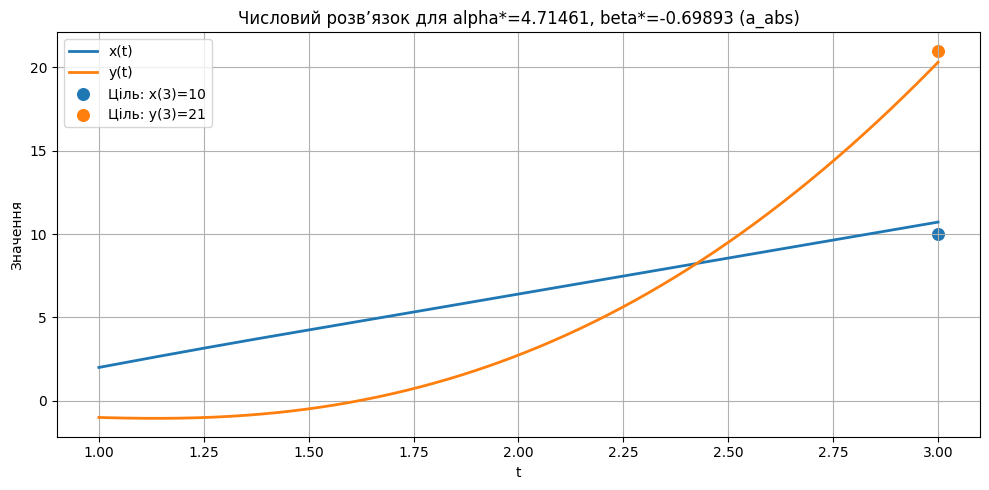

---------------------------------------------------------------

Пункт b_square

best params = [4.19261541 0.39230308]
f(best) = 0.02721713
Зараз виконується обчислення поверхні для завдання b
Успішно збережено! task4_cuckoo_b_square.gif
---------------------------------------------------------------

Пункт c_max

best params = [4.39964816 0.06599865]
f(best) = 0.42514478
Зараз виконується обчислення поверхні для завдання c
Успішно збережено! task4_cuckoo_c_max.gif
---------------------------------------------------------------


In [ ]:
# межі відрізка і цільові значення
XA4 = 1.0
XB4 = 3.0
X_TARGET4 = 10.0
Y_TARGET4 = 21.0

# межі відрізка і цільові значення
N4 = 1000
N_SURFACE4 = 220

# права частина системи
def system_rhs_task4_lab(t, state):
    x, vx, y, vy = state

    x = np.clip(x, -50, 50)
    y = np.clip(y, -50, 50)
    vx = np.clip(vx, -30, 30)
    vy = np.clip(vy, -30, 30)

    ddx = np.cos(x * y) - np.sin(y + t * x) / (((x ** 2 + vy) ** 2) + 1.0)
    ddy = (
        6.0 * t
        - 1.0 / (t ** 4)
        + np.cos(5.0)
        - 4.0
        + vy / (t ** 2)
        - np.cos(3.0 * x - vy)
        + x ** 2 / (t ** 4)
    )

    return np.array([vx, ddx, vy, ddy], dtype=float)


# Розв'язання системи методом Ейлера
def euler_solve_task4_lab(alpha, beta, n_nodes=N4):
    h = (XB4 - XA4) / (n_nodes - 1)
    t_vals = np.linspace(XA4, XB4, n_nodes)

    # початкові умови
    state = np.array([2.0, float(alpha), -1.0, float(beta)], dtype=float)

    x_hist = [state[0]]
    vx_hist = [state[1]]
    y_hist = [state[2]]
    vy_hist = [state[3]]


    for k in range(n_nodes - 1):
        t = t_vals[k]

        # зупинка при нестійкості
        if np.any(~np.isfinite(state)):
            break
        if np.max(np.abs(state)) > 1e6:
            break

        state = state + h * system_rhs_task4_lab(t, state)

        x_hist.append(state[0])
        vx_hist.append(state[1])
        y_hist.append(state[2])
        vy_hist.append(state[3])

    used = len(x_hist)
    return (
        t_vals[:used],
        np.array(x_hist),
        np.array(vx_hist),
        np.array(y_hist),
        np.array(vy_hist),
    )


# похибки на правій межі
def get_terminal_errors_task4_lab(alpha, beta, n_nodes=N4):
    t, x, vx, y, vy = euler_solve_task4_lab(alpha, beta, n_nodes=n_nodes)

    if len(x) == 0 or len(y) == 0:
        return None
    if not np.isfinite(x[-1]) or not np.isfinite(y[-1]):
        return None

    ex = x[-1] - X_TARGET4
    ey = y[-1] - Y_TARGET4
    return ex, ey, t, x, y


# цільова функція a)
def f_abs_task4_lab(params, m=1.0, n=1.0, n_nodes=N4):
    alpha, beta = params
    res = get_terminal_errors_task4_lab(alpha, beta, n_nodes=n_nodes)
    if res is None:
        return 1e9
    ex, ey, _, _, _ = res
    return m * abs(ex) + n * abs(ey)

# цільова функція b)
def f_square_task4_lab(params, m=1.0, n=1.0, n_nodes=N4):
    alpha, beta = params
    res = get_terminal_errors_task4_lab(alpha, beta, n_nodes=n_nodes)
    if res is None:
        return 1e9
    ex, ey, _, _, _ = res
    return m * ex ** 2 + n * ey ** 2

# цільова функція c)
def f_max_task4_lab(params, m=1.0, n=1.0, n_nodes=N4):
    alpha, beta = params
    res = get_terminal_errors_task4_lab(alpha, beta, n_nodes=n_nodes)
    if res is None:
        return 1e9
    ex, ey, _, _, _ = res
    return max(m * abs(ex), n * abs(ey))

# метод зозулі для 2 параметрів
def cuckoo_search_task4_lab(func, bounds, n_nests=25, n_iter=80, pa=0.25):
    lower, upper = bounds

    nests = np.random.uniform(lower, upper, size=(n_nests, 2))
    fitness = np.array([func(p) for p in nests])

    best_idx = np.argmin(fitness)
    best = nests[best_idx].copy()
    best_val = fitness[best_idx]

    convergence = []
    nest_history = []
    fitness_history = []

    for _ in range(n_iter):
        nest_history.append(nests.copy())
        fitness_history.append(fitness.copy())

        for i in range(n_nests):
            step = levy_flight(2)
            new = nests[i] + 0.01 * step * (best - nests[i])
            new = np.clip(new, lower, upper)

            f_new = func(new)
            if f_new < fitness[i]:
                nests[i] = new
                fitness[i] = f_new

        # випадкове оновлення частини точок
        abandon = np.random.rand(n_nests) < pa
        nests[abandon] = np.random.uniform(lower, upper, size=(np.sum(abandon), 2))

        for j in np.where(abandon)[0]:
            fitness[j] = func(nests[j])

        # випадкове оновлення частини точок
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_val:
            best = nests[best_idx].copy()
            best_val = fitness[best_idx]

        convergence.append(best_val)

    nest_history.append(nests.copy())
    fitness_history.append(fitness.copy())

    return convergence, best, best_val, nest_history, fitness_history

# анімація з 4 графіками
def animate_task4_final(nest_history, fitness_history, convergence, func_surface, bounds, title, filename, task_label):
    convergence = np.array(convergence, dtype=float)

    n_frames = len(convergence)
    n_nests = nest_history[0].shape[0]

    lower, upper = bounds
    a_min, b_min = lower
    a_max, b_max = upper

    grid_n = 15
    alpha_grid = np.linspace(a_min, a_max, grid_n)
    beta_grid = np.linspace(b_min, b_max, grid_n)
    A, B = np.meshgrid(alpha_grid, beta_grid)

    print(f"Зараз виконується обчислення поверхні для завдання {task_label}")

    Z = np.zeros_like(A, dtype=float)
    for i in range(grid_n):
        for j in range(grid_n):
            Z[i, j] = func_surface(np.array([A[i, j], B[i, j]]))
            Z[i, j] = np.clip(Z[i, j], 0, 1e5)

    z_min = np.min(Z)
    z_max = np.max(Z)

    max_hist_count = n_nests
    conv_min = np.min(convergence)
    conv_max = np.max(convergence)
    pad = 0.05 * (conv_max - conv_min + 1e-12)

    fig = plt.figure(figsize=(12, 9))
    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3)
    ax4 = fig.add_subplot(2, 2, 4)

    def update(frame):
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()

        nests = nest_history[frame]
        vals = fitness_history[frame]

         # 3D графік
        ax1.plot_surface(A, B, Z, cmap="viridis", edgecolor="none", alpha=0.85)
        ax1.scatter(nests[:, 0], nests[:, 1], vals, c="red", s=35, depthshade=True)
        ax1.set_title("Об'ємний графік функції")
        ax1.set_xlabel("alpha")
        ax1.set_ylabel("beta")
        ax1.set_zlabel("f(alpha, beta)")
        ax1.set_xlim(a_min, a_max)
        ax1.set_ylim(b_min, b_max)
        ax1.set_zlim(z_min, z_max)

        # контурний графік
        ax2.contourf(A, B, Z, levels=30, cmap="plasma")
        ax2.contour(A, B, Z, levels=12, colors="navy", linewidths=0.5)
        ax2.scatter(nests[:, 0], nests[:, 1], c="red", s=45, edgecolors="goldenrod")
        ax2.set_title("Контурний графік")
        ax2.set_xlabel("alpha")
        ax2.set_ylabel("beta")
        ax2.set_xlim(a_min, a_max)
        ax2.set_ylim(b_min, b_max)

        # гістограма
        ax3.hist(vals, bins=min(12, n_nests), edgecolor="black")
        ax3.set_title("Розподіл значень")
        ax3.set_xlabel("f(alpha, beta)")
        ax3.set_ylabel("Кількість")
        ax3.set_xlim(z_min, z_max)
        ax3.set_ylim(0, max_hist_count)

        # гістограма
        ax4.plot(range(1, frame + 2), convergence[:frame + 1], marker="*", linewidth=1)
        ax4.set_title("Графік оптимальної відстані")
        ax4.set_xlabel("Ітерація")
        ax4.set_ylabel("Найкраще значення")
        ax4.set_xlim(1, n_frames)
        ax4.set_ylim(conv_min - pad, conv_max + pad)
        ax4.grid(True, alpha=0.4)

        fig.suptitle(f"{title} | Ітерація {frame + 1}/{n_frames}", fontsize=14)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=180)
    anim.save(filename, writer="pillow", fps=6)
    plt.close(fig)
    print(f"Успішно збережено! {filename}")


def plot_solution_task4_final(best_params, label):
    alpha_star, beta_star = best_params
    res = get_terminal_errors_task4_lab(alpha_star, beta_star, n_nodes=N4)

    if res is None:
        print(f"Для {label} отримано нестійкий розв'язок.")
        return

    ex, ey, t, x, y = res

    print()
    print(f"Розв'язок ({label})")
    print(f"alpha* = {alpha_star:.8f}")
    print(f"beta*  = {beta_star:.8f}")
    print(f"x(3)   = {x[-1]:.8f}")
    print(f"y(3)   = {y[-1]:.8f}")
    print(f"|x(3)-10| = {abs(ex):.8e}")
    print(f"|y(3)-21| = {abs(ey):.8e}")

    plt.figure(figsize=(10, 5))
    plt.plot(t, x, label="x(t)", linewidth=2)
    plt.plot(t, y, label="y(t)", linewidth=2)
    plt.scatter([3], [10], s=70, label="Ціль: x(3)=10")
    plt.scatter([3], [21], s=70, label="Ціль: y(3)=21")
    plt.grid(True)
    plt.xlabel("t")
    plt.ylabel("Значення")
    plt.title(f"Числовий розв’язок для alpha*={alpha_star:.5f}, beta*={beta_star:.5f} ({label})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_case_task4_final(name, func_opt, func_surface, bounds, file_name, task_label, show_plot=False):
    conv, best, best_val, hist, fit_hist = cuckoo_search_task4_lab(
        func_opt,
        bounds=bounds,
        n_nests=25,
        n_iter=80,
        pa=0.25,
    )

    print("---------------------------------------------------------------")
    print()
    print(f"Пункт {name}")
    print()
    print(f"best params = {best}")
    print(f"f(best) = {best_val:.8f}")

    animate_task4_final(
        hist,
        fit_hist,
        conv,
        func_surface,
        bounds,
        title=f"Метод зозулі | варіант {name}",
        filename=file_name,
        task_label=task_label
    )

    if show_plot:
        print()
        plot_solution_task4_final(best, name)

# запуск всього завдання
def run_task4_final():
    np.random.seed(42)

    lower = np.array([-8.0, -8.0])
    upper = np.array([8.0, 8.0])
    bounds = (lower, upper)

    m = 1.0
    n = 1.0

    print()
    print("---------------------------------------------------------------")
    print("Завдання 4")
    print()

    func_a = lambda p: f_abs_task4_lab(p, m=m, n=n, n_nodes=N4)
    func_b = lambda p: f_square_task4_lab(p, m=m, n=n, n_nodes=N4)
    func_c = lambda p: f_max_task4_lab(p, m=m, n=n, n_nodes=N4)

    func_a_surface = lambda p: f_abs_task4_lab(p, m=m, n=n, n_nodes=N_SURFACE4)
    func_b_surface = lambda p: f_square_task4_lab(p, m=m, n=n, n_nodes=N_SURFACE4)
    func_c_surface = lambda p: f_max_task4_lab(p, m=m, n=n, n_nodes=N_SURFACE4)

    run_case_task4_final(
        name="a_abs",
        func_opt=func_a,
        func_surface=func_a_surface,
        bounds=bounds,
        file_name="task4_cuckoo_a_abs.gif",
        task_label="а",
        show_plot=True
    )

    run_case_task4_final(
        name="b_square",
        func_opt=func_b,
        func_surface=func_b_surface,
        bounds=bounds,
        file_name="task4_cuckoo_b_square.gif",
        task_label="b",
        show_plot=False
    )

    run_case_task4_final(
        name="c_max",
        func_opt=func_c,
        func_surface=func_c_surface,
        bounds=bounds,
        file_name="task4_cuckoo_c_max.gif",
        task_label="c",
        show_plot=False
    )

    print("---------------------------------------------------------------")


run_task4_final()